In [1]:
import mne 
import pandas as pd
import numpy as np
import pathlib


In [2]:
raw = mne.io.read_raw_bdf(r"C:\Users\Marcio Neves\Documents\Doutorado\dados\Motor_imagery\EDVALDO CAVALCANTE DE QUEIROZ.bdf")

Extracting BDF parameters from C:\Users\Marcio Neves\Documents\Doutorado\dados\Motor_imagery\EDVALDO CAVALCANTE DE QUEIROZ.bdf...
Setting channel info structure...
Creating raw.info structure...


In [3]:
print(raw)

<RawBDF | EDVALDO CAVALCANTE DE QUEIROZ.bdf, 73 x 936960 (915.0 s), ~73 KiB, data not loaded>


In [4]:
print(raw.info['sfreq'])

1024.0


In [5]:
print(raw.ch_names)

['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1', 'P3', 'P5', 'P7', 'P9', 'PO7', 'PO3', 'O1', 'Iz', 'Oz', 'POz', 'Pz', 'CPz', 'Fpz', 'Fp2', 'AF8', 'AF4', 'AFz', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT8', 'FC6', 'FC4', 'FC2', 'FCz', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP8', 'CP6', 'CP4', 'CP2', 'P2', 'P4', 'P8', 'P6', 'P10', 'PO8', 'PO4', 'O2', 'EXG1', 'EXG2', 'EXG3', 'EXG4', 'EXG5', 'EXG6', 'EXG7', 'EXG8', 'Status']


In [6]:
data = raw.get_data()

In [7]:
data

array([[-9.58627916e-03, -9.57715418e-03, -9.64784155e-03, ...,
        -9.87446613e-03, -9.88509111e-03, -9.88193487e-03],
       [-1.28470231e-02, -1.28321794e-02, -1.28941481e-02, ...,
        -1.17999001e-02, -1.18096813e-02, -1.18050563e-02],
       [-2.26907237e-02, -2.26767862e-02, -2.27384736e-02, ...,
        -1.91396990e-02, -1.91520740e-02, -1.91483552e-02],
       ...,
       [-2.00000115e-01, -2.00000115e-01, -2.00000115e-01, ...,
        -2.00000115e-01, -2.00000115e-01, -2.00000115e-01],
       [-2.00000115e-01, -2.00000115e-01, -2.00000115e-01, ...,
        -2.00000115e-01, -2.00000115e-01, -2.00000115e-01],
       [ 1.31071000e+05,  6.55350000e+04,  6.55350000e+04, ...,
         6.55350000e+04,  6.55350000e+04,  6.55350000e+04]])

In [8]:
times = raw.times

In [9]:
times

array([0.00000000e+00, 9.76562500e-04, 1.95312500e-03, ...,
       9.14997070e+02, 9.14998047e+02, 9.14999023e+02])

In [10]:
raw_eeg = raw.copy().pick_types(eeg=True, eog=False, stim=False, exclude="bads")

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


In [11]:
raw_eeg

<RawBDF | EDVALDO CAVALCANTE DE QUEIROZ.bdf, 72 x 936960 (915.0 s), ~72 KiB, data not loaded>

In [12]:
raw_eeg.load_data()
raw_eeg = raw_eeg.set_eeg_reference("average")
raw_eeg = raw_eeg.filter(l_freq=1.0, h_freq=40.0)

Reading 0 ... 936959  =      0.000 ...   914.999 secs...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3381 samples (3.302 s)



Using matplotlib as 2D backend.


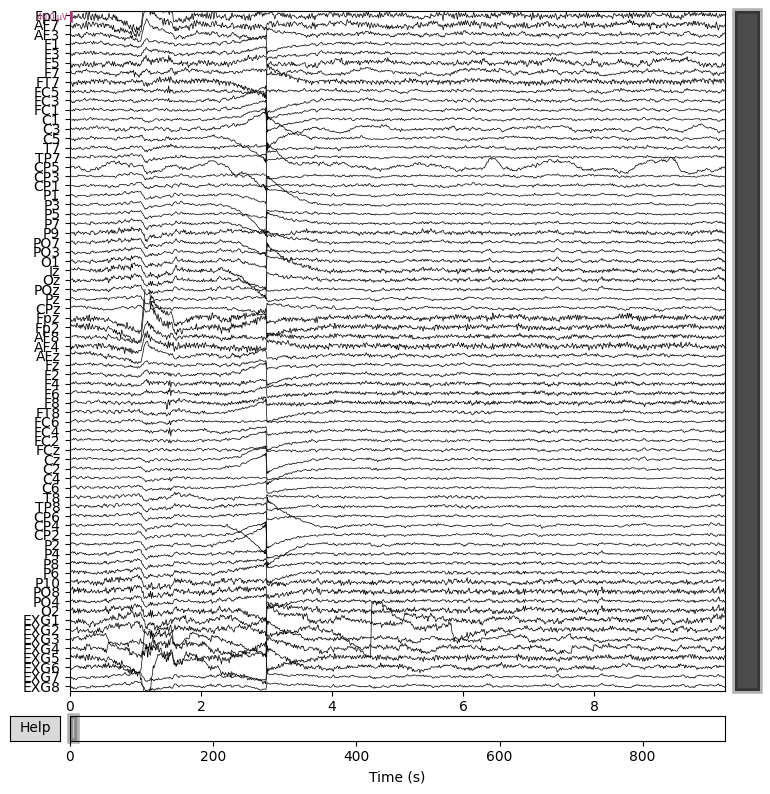

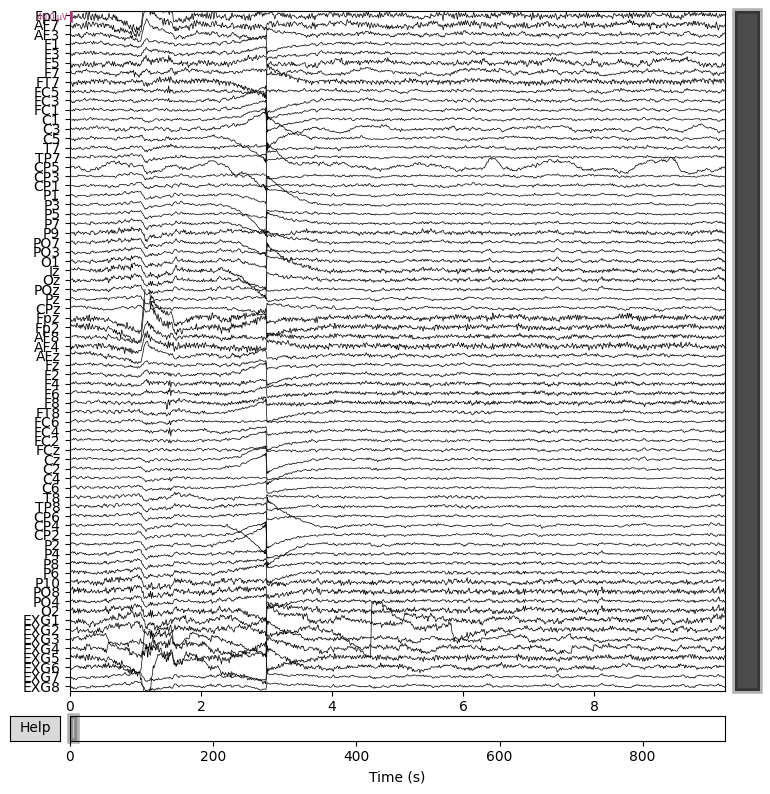

In [13]:
raw_eeg.plot(
    duration=10,   # segundos visíveis por vez
    n_channels=72  # quantos canais mostrar
)

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 2.000 (s)
Plotting power spectral density (dB=True).


C:\Users\Marcio Neves\AppData\Local\Temp\ipykernel_14676\2055971021.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_eeg.plot_psd(fmin=1, fmax=40)
c:\Users\Marcio Neves\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


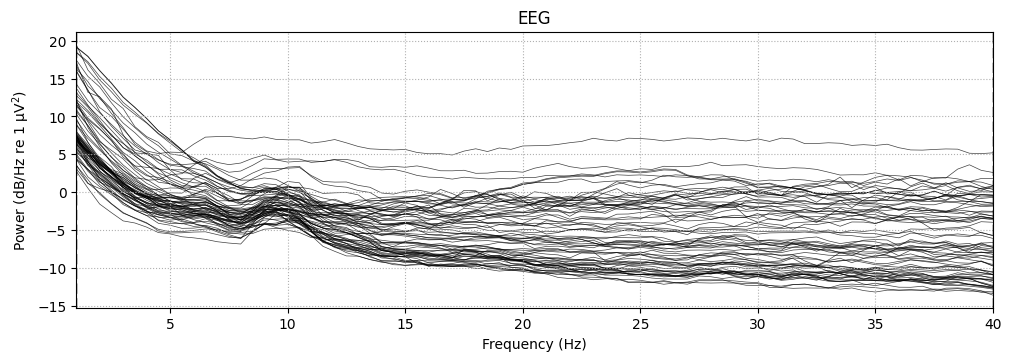

In [14]:
raw_eeg.plot_psd(fmin=1, fmax=40)

In [15]:
raw_topo = raw_eeg.copy().pick_types(eeg=True)
raw_topo.drop_channels([f"EXG{i}" for i in range(1, 9) if f"EXG{i}" in raw_topo.ch_names])
raw_topo.plot_psd_topomap(fmin=1, fmax=40)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
Effective window size : 2.000 (s)


RuntimeError: No digitization points found.

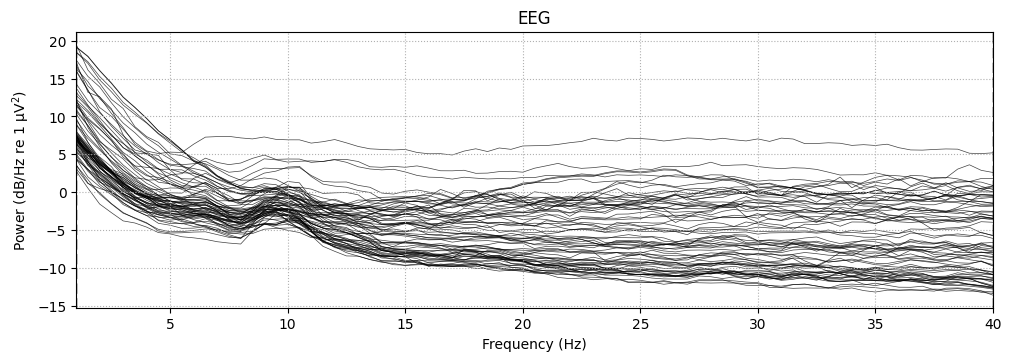

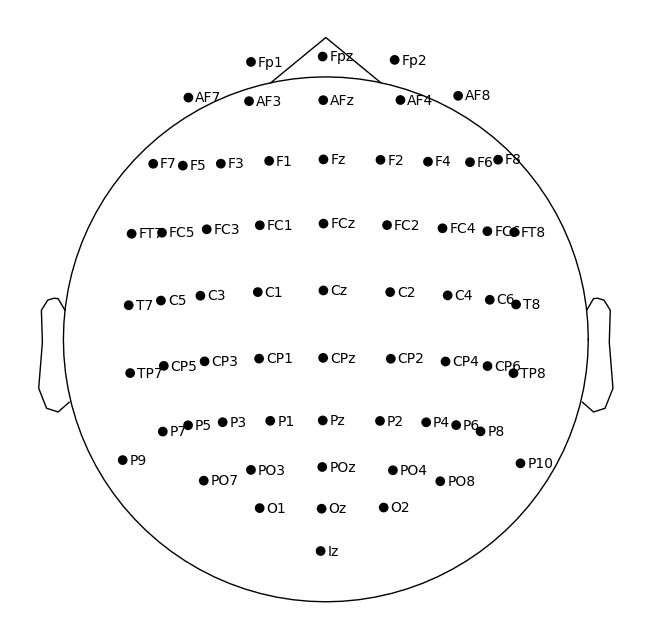

NOTE: plot_psd_topomap() is a legacy function. New code should use .compute_psd().plot_topomap().
Effective window size : 2.000 (s)


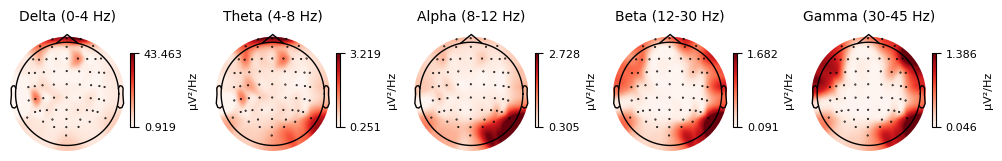

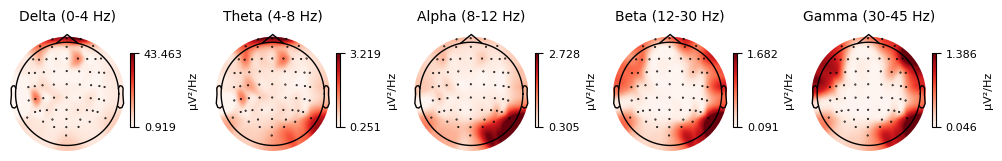

In [16]:
montage = mne.channels.make_standard_montage("standard_1020")
raw_topo.set_montage(montage, on_missing="ignore")

raw_topo.plot_sensors(show_names=True)
raw_topo.plot_psd_topomap()

# Preprocessing and KMeans

In [17]:
import numpy as np
import mne

# cópia para preservar o original
raw = raw_eeg.copy()

# filtro básico (ajuste conforme seu protocolo)
raw.filter(l_freq=1.0, h_freq=40.0)

# opcional: remover artefatos com ICA
# ica = mne.preprocessing.ICA(n_components=20, random_state=42, max_iter="auto")
# ica.fit(raw)
# raw = ica.apply(raw.copy())

# criar eventos igualmente espaçados para janelas contínuas
events = mne.make_fixed_length_events(raw, duration=2.0, overlap=1.0)

epochs = mne.Epochs(
    raw,
    events,
    tmin=0.0,
    tmax=2.0,
    baseline=None,
    preload=True,
    reject_by_annotation=True
)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3381 samples (3.302 s)

Not setting metadata
914 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 914 events and 2049 original time points ...
1 bad epochs dropped


In [18]:
from mne.time_frequency import psd_array_welch

# dados no formato: (n_epochs, n_channels, n_times)
X_epochs = epochs.get_data()
sfreq = epochs.info["sfreq"]

# calcular PSD
psds, freqs = psd_array_welch(
    X_epochs,
    sfreq=sfreq,
    fmin=1,
    fmax=40,
    n_fft=256,
    verbose=False
)

# bandas clássicas
bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 40)
}

# construir features: potência média por banda em cada canal
features = []
for band_name, (fmin, fmax) in bands.items():
    idx = (freqs >= fmin) & (freqs < fmax)
    band_power = psds[:, :, idx].mean(axis=2)   # (n_epochs, n_channels)
    features.append(band_power)

# concatena tudo: (n_epochs, n_channels * n_bands)
X = np.concatenate(features, axis=1)

print("Shape das features:", X.shape)

Shape das features: (913, 360)


C:\Users\Marcio Neves\AppData\Local\Temp\ipykernel_14676\1105059823.py:30: RuntimeWarning: Mean of empty slice.
  band_power = psds[:, :, idx].mean(axis=2)   # (n_epochs, n_channels)
c:\Users\Marcio Neves\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [21]:
import numpy as np

print("X shape:", X.shape)
print("NaNs em X:", np.isnan(X).sum())
print("Inf em X:", np.isinf(X).sum())

print("NaNs por linha (primeiras 10):", np.isnan(X).sum(axis=1)[:10])
print("NaNs por coluna (primeiras 10):", np.isnan(X).sum(axis=0)[:10])

rows_with_nan = np.where(np.isnan(X).any(axis=1))[0]
cols_with_nan = np.where(np.isnan(X).any(axis=0))[0]

print("Linhas com NaN:", rows_with_nan[:20])
print("Colunas com NaN:", cols_with_nan[:20])

X shape: (913, 360)
NaNs em X: 65736
Inf em X: 0
NaNs por linha (primeiras 10): [72 72 72 72 72 72 72 72 72 72]
NaNs por coluna (primeiras 10): [913 913 913 913 913 913 913 913 913 913]
Linhas com NaN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Colunas com NaN: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


In [22]:
X_epochs = epochs.get_data()
print("Shape epochs:", X_epochs.shape)
print("NaNs nas epochs:", np.isnan(X_epochs).sum())
print("Inf nas epochs:", np.isinf(X_epochs).sum())

Shape epochs: (913, 72, 2049)
NaNs nas epochs: 0
Inf nas epochs: 0


In [23]:
for band_name, (fmin, fmax) in bands.items():
    idx = (freqs >= fmin) & (freqs < fmax)
    print(f"{band_name}: {idx.sum()} bins")
    if idx.sum() > 0:
        print("  freqs:", freqs[idx][:10], "...")
    else:
        print("  SEM BINS VÁLIDOS")

delta: 0 bins
  SEM BINS VÁLIDOS
theta: 1 bins
  freqs: [4.] ...
alpha: 2 bins
  freqs: [ 8. 12.] ...
beta: 4 bins
  freqs: [16. 20. 24. 28.] ...
gamma: 2 bins
  freqs: [32. 36.] ...


In [24]:
import numpy as np
import mne
from mne.time_frequency import psd_array_welch

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

raw = raw_eeg.copy()
raw.load_data()

# filtro
raw.filter(l_freq=1.0, h_freq=40.0)

# janelas maiores
events = mne.make_fixed_length_events(raw, duration=4.0, overlap=2.0)

epochs = mne.Epochs(
    raw,
    events,
    tmin=0.0,
    tmax=4.0,
    baseline=None,
    preload=True,
    reject_by_annotation=True,
    verbose=False
)

X_epochs = epochs.get_data()
sfreq = epochs.info["sfreq"]

print("Shape das epochs:", X_epochs.shape)
print("sfreq:", sfreq)

# PSD com n_fft maior
n_times = X_epochs.shape[-1]
n_fft = min(512, n_times)   # pode testar 256, 512 ou 1024 se houver amostras suficientes

psds, freqs = psd_array_welch(
    X_epochs,
    sfreq=sfreq,
    fmin=1,
    fmax=40,
    n_fft=n_fft,
    n_per_seg=n_fft,
    verbose=False
)

print("Primeiras frequências:", freqs[:20])

bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 40)
}

feature_blocks = []
valid_band_names = []

for band_name, (fmin, fmax) in bands.items():
    idx = (freqs >= fmin) & (freqs < fmax)
    print(f"{band_name}: {idx.sum()} bins")

    if idx.sum() == 0:
        print(f"  -> banda ignorada")
        continue

    band_power = psds[:, :, idx].mean(axis=2)
    feature_blocks.append(band_power)
    valid_band_names.append(band_name)

X = np.concatenate(feature_blocks, axis=1)

print("Bandas usadas:", valid_band_names)
print("Shape X:", X.shape)
print("NaNs em X:", np.isnan(X).sum())

# segurança extra
mask_valid = ~np.isnan(X).any(axis=1)
X = X[mask_valid]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Shape após PCA:", X_pca.shape)

best_k = None
best_score = -1
best_model = None

for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    print(f"k={k} | silhouette={score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k
        best_model = model

print("\nMelhor k:", best_k)
print("Melhor silhouette:", best_score)

labels = best_model.labels_

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3381 samples (3.302 s)

Shape das epochs: (456, 72, 4097)
sfreq: 1024.0
Primeiras frequências: [ 2.  4.  6.  8. 10. 12. 14. 16. 18. 20. 22. 24. 26. 28. 30. 32. 34. 36.
 38. 40.]
delta: 1 bins
theta: 2 bins
alpha: 3 bins
beta: 8 bins
gamma: 5 bins
Bandas usadas: ['delta', 'theta', 'alpha', 'beta', 'gamma']
Shape X: (456, 360)
NaNs em X: 0
Shape após PCA: (456, 71)
k=2 | silhouette=0.2705
k=3 | silhouette=0.2919
k=4 | silhouette=0.2947
k=5 | silhouette=0.2652


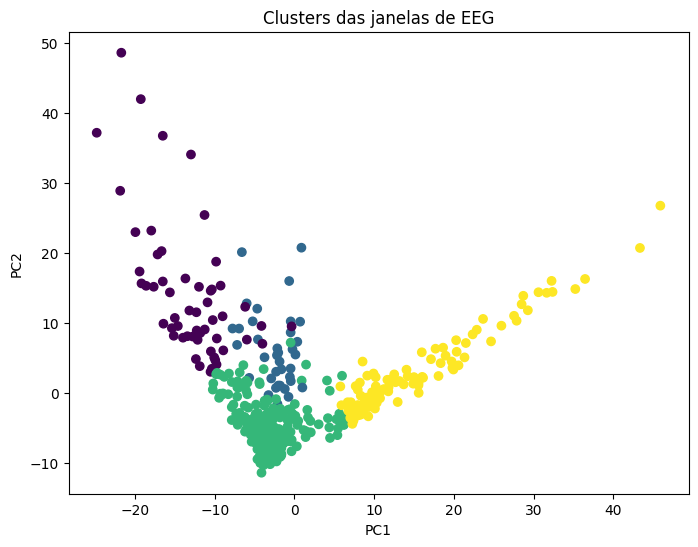

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters das janelas de EEG")
plt.show()